## 02-2 데이터 처리
---

### 넘파이로 데이터 준비하기


In [2]:
from tarfile import TarInfo

# 생선 데이터 준비
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

import numpy as np

- 넘파이의 `column_stack()` 함수는 전달받은 리스트를 일렬로 세운 다음 차례대로 나란히 연결한다.

In [3]:
np.column_stack(([1,2,3], [4,5,6]))


array([[1, 4],
       [2, 5],
       [3, 6]])

해당 함수를 사용하여 `fish_length`, `fish_weight`를 합친다.

In [43]:
fish_data = np.column_stack((fish_length, fish_weight))

print(fish_data[:5])

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


다음과 같이 두 데이터를 열로 합친 후 5개의 행, 2개의 열을 출력했다.\
이와 같은 동일한 방법으로 타깃 데이터도 만들어 본다.

   -  `np.ones()`와 `np.zeros()` 함수를 이용하여 만든다.


In [44]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)), axis=0)
print(target_data)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


---

#### [배열 쌓기]

- `np.vstack()` : 세로 방향(행 기준)으로 쌓기
    - 기존 배열을 위-> 아래로 붙이는 것이기 때문에, 열 개수가 같아야 한다.


- `np.hstack()` : 가로 방향(열 기준)으로 쌓기
    - 좌 -> 우로 붙이기 때문에, 행 개수가 같아야 한다.


- `np.concatenate()` : 원하는 축(axis) 기준으로 붙이기
    - `vstack`(axis = 0), `hstack`(axis = 1)의 상위 개념


- `np.stack()` : 아예 새로운 축을 만들어서 쌓는다

In [23]:
q1 = np.full((3,4), 1)
q2 = np.full((4,4), 2)
q3 = np.full((3,4), 3)

q4 = np.vstack((q1, q2, q3))
print(q4)

q5 = np.hstack((q1, q3))
# print(q5)

q7 = np.concatenate((q1, q3), axis=1)
print(q7)

q8 = np.stack((q1, q3))
print(q8)

[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [2 2 2 2]
 [2 2 2 2]
 [2 2 2 2]
 [2 2 2 2]
 [3 3 3 3]
 [3 3 3 3]
 [3 3 3 3]]
[[1 1 1 1 3 3 3 3]
 [1 1 1 1 3 3 3 3]
 [1 1 1 1 3 3 3 3]]
[[[1 1 1 1]
  [1 1 1 1]
  [1 1 1 1]]

 [[3 3 3 3]
  [3 3 3 3]
  [3 3 3 3]]]


---

### 사이킷런으로 훈련 세트와 테스트 세트 나누기
사이킷런은 머신러닝 모델을 위한 알고리즘뿐 아니라 다양한 유틸리티 도구도 제공하고 있다.
- 대표적인 도구가 바로 `train_test_split()`이다.
- 전달되는 리스트나 배열을 비율에 맞게 훈련세트와 테스트 세트로 나눠준다.



In [45]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42
)

print(test_target)

[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


- `train_test_split()`은 기본적으로 25%를 테스트 세트로 떼어 낸다.
- 원래 데이터 비율이 35:14 (2.5:1)인데, 분할 후 3.3:1로 깨질 수 있다. => **샘플링 편향**

<br>

- `stratify` 매개 변수에 타깃 데이터를 전달하면 이러면 클래스 비율에 맞게 데이터를 나눌 수 있다.

In [46]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, stratify=fish_target,random_state=42
)

print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


---

### 수상한 도미 한 마리
이제 데이터는 다 준비되었으니 모델을 훈련하고 평가해보겠다.

In [47]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

kn.fit(train_input, train_target)
kn.score(test_input, test_target)

print(kn.predict([[25, 150]]))

[0.]


이전의 모델 학습에서 문제점은 다음과 같았다:\
&rarr; 길이가 25cm이고 무게가 150g이면 도미인데 모델에서는 빙어라고 예측했던 것이었다.

<br>
그러나 지금도 여전히 동일한 결과가 나오고 있다.<br>
산점도를 그려서 확인해보자.

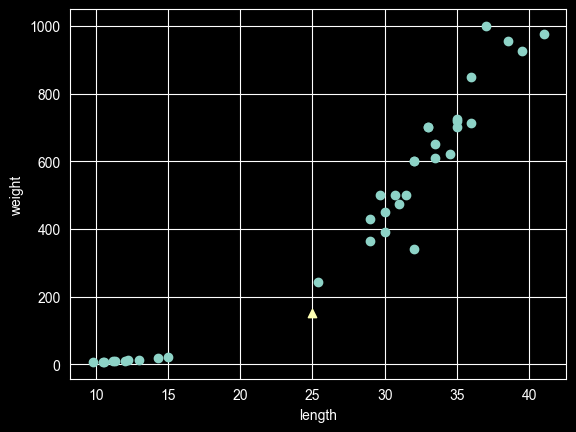

In [48]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

분명 그래프에서 입력한 `[25, 150]` 데이터는 위로 뻗어 있는 도미 데이터에 가까움에도 불구하고,<br>
&rArr; 예측은 빙어로 나왔다.
<br>
<br>

#### 왜 그럴까?
k-최근접 이웃은 주변의 샘플 중에서 다수인 클래스를 예측으로 사용한다.\
&rArr; 이웃까지의 거리와 이웃 샘플의 인덱스를 반환하는 `kneighbors()`메서드를 사용해서 확인해보자

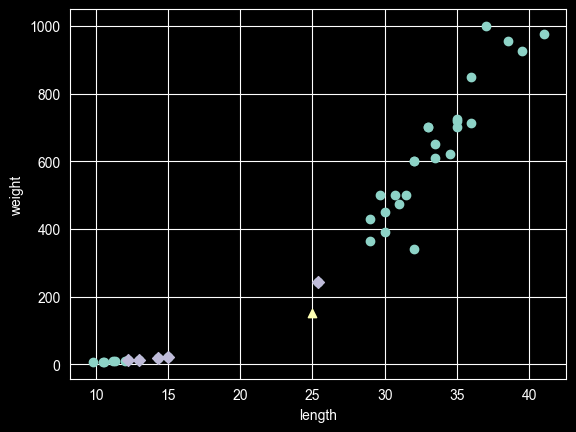

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]
[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


In [55]:
distance, indexes = kn.kneighbors([[25, 150]])

plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
# 샘플에서 가장 가까운 이웃들 표시
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker="D")

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

print(train_input[indexes])
print(train_target[indexes])

- 가장 가까운 이웃 중에 도미는 1개, 빙어가 4개가 포함되어 있었다.

---

### 기준을 맞춰라


In [56]:
print(distance)

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


`distance` 배열을 보면 가장 가까운 샘플과의 거리가 92이고 그외는 130이상이다.\
실제 그래프를 확인해보면 거리 비율이 이상하다는 것을 눈치 챌 수 있다.

<br>
그 이유는 다음과 같다:<br>
&rArr; x축은 범위가 좁고 (10~40), y축은 범위가 범위가 넓다(0~1000).<br>
&rArr; 따라서, y축으로 초금만 멀어져도 거리가 아주 큰 값으로 계산되어서 선택될 수 없던 것이다.
<br>
<br>
명확하게 확인해보면 다음과 같다.

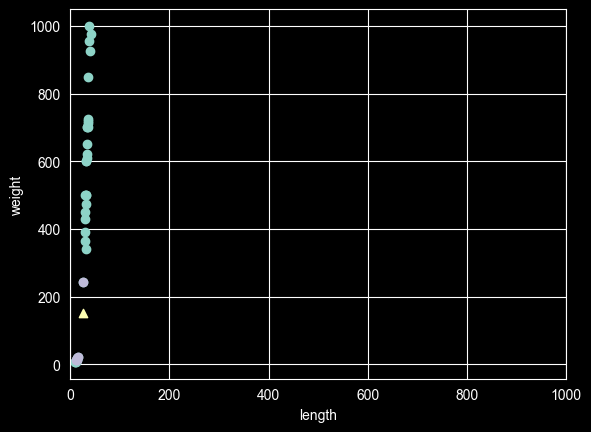

In [57]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.scatter(train_input[indexes, 0], train_input[indexes, 1])

# x축 범위를 동일하게 설정해서 비교해본다 (y축 범위를 지정하려면 ".ylim()")
plt.xlim((0, 1000))
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

정리하자면, 생선의 길이(x축)은 가장 가까운 이웃을 찾는 데 큰 영향을 미치지 못했다.<br>
&rArr; 이를 우리는 두 특성의 **스케일(scale)** 이 다르다고 말한다.
<br>
- 예를 들면, 방의 넓이를 잴 때, 가로는 `inch`로 재고 세로는 `cm`로 잰 것이다

<br>
<br>
이러한 일들은 알고리즘이 거리 기반일 때 특히 발생한다.<br>
&rArr; 따라서, 우리는 특성값을 일정한 기준으로 맞춰주어야 한다.<br>

이를 **데이터 전처리(data preprocessing)** 이라고 부른다.

<br>
<br>

가장 널리 사용하는 방법 중 하나가 바로 **표준점수(standard score)** 이다.
- 표준 점수는 각 특성값이 평균에서 표준편차의 몇 배만큼 떨어져 있는지를 나타낸다.

In [58]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
print(mean, std)

train_scaled = (train_input - mean) / std
print(train_scaled)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]
[[ 0.24070039  0.14198246]
 [-1.51237757 -1.36683783]
 [ 0.5712808   0.76060496]
 [-1.60253587 -1.37766373]
 [ 1.22242404  1.45655528]
 [ 0.17057727 -0.07453542]
 [ 0.87180845  0.80390854]
 [ 0.87180845  1.22457184]
 [ 0.37092904  0.06465464]
 [ 0.77163257  0.82246721]
 [ 0.97198434  1.68853872]
 [-1.61255346 -1.3742613 ]
 [ 0.72154463  0.51315596]
 [-1.53241275 -1.3742613 ]
 [ 0.17057727 -0.28177396]
 [ 0.5712808   0.76060496]
 [ 0.34087627  0.14198246]
 [ 1.12224816  1.54934866]
 [ 0.62136874  0.60594934]
 [-1.30200822 -1.34363949]
 [ 0.42101698  0.14198246]
 [-0.19005591 -0.65604058]
 [-1.75279969 -1.38384995]
 [ 0.47110492  0.45129371]
 [-1.68267658 -1.38137546]
 [ 0.62136874  0.48222484]
 [-1.67265899 -1.38292202]
 [ 0.77163257  0.76060496]
 [ 0.47110492  0.45129371]
 [ 0.77163257  0.83793278]
 [-1.43223687 -1.36683783]
 [ 0.27075315 -0.01267317]
 [ 0.47110492 -0.35291555]
 [-1.2318851  -1.34302087]
 [ 0.27075315 -0.19825992]

위의 연산이 가능한 이유는 넘파이에 **브로드캐스팅(broadcasting)** 이라는 기능이 있기 때문이다.

---

### 전처리 데이터로 모델 훈련하기
이제는 샘플 데이터도 위에서 전처리 과정에서 사용한 동일한 `mean`, `std` 기준을 사용해서 동일한 비율로 변환시킨 후 다시 그려보자.

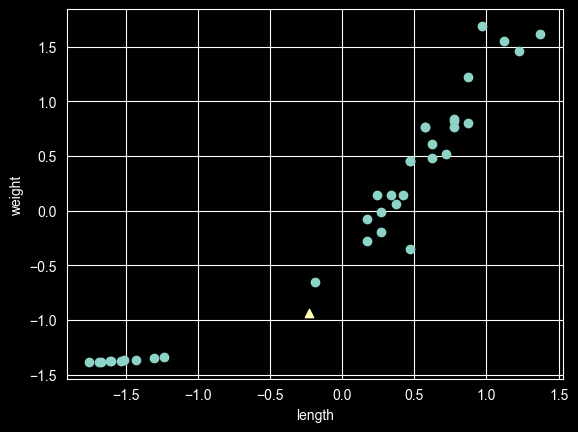

In [59]:
new = ([25, 150] - mean)/std

plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker="^")

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

In [60]:
kn.fit(train_scaled, train_target)

# 테스트 세트로 평가할 때에도 스케일을 해주어야 한다.
# 단, 앞서 사용한 훈련 세트의 평균과 표준편차를 사용해서 변환해주어야 한다.
# 그렇지 않으면 스케일이 같지 않아 쓸모없어 질 수 있다.
test_scaled = (test_input - mean) / std

kn.score(test_scaled, test_target)

1.0

In [61]:
print(kn.predict([new]))

[1.]
